# Loan Status Prediction

This notebook builds a **Support Vector Machine (SVM)** model that predicts whether a loan application will be **approved (Y)** or **rejected (N)** based on applicant details such as income, credit history, education, and property area.

**Dataset:** `train_loan_data.csv` (place this file in the same folder as this notebook).

> Note: This notebook was originally written for Google Colab (paths like `/content/...`). It has been updated to run locally / on any Jupyter environment using a relative file path.

## 1. Importing the Dependencies

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn.metrics import accuracy_score


## 2. Data Collection and Processing

In [2]:
# loading the dataset to a pandas DataFrame
# Make sure 'train_loan_data.csv' is in the same folder as this notebook
loan_dataset = pd.read_csv('train_loan_data.csv')


In [3]:
type(loan_dataset)

<class 'pandas.DataFrame'>

In [4]:
# printing the first 5 rows of the dataframe
loan_dataset.head()


    Loan_ID  Gender Married  ... Credit_History Property_Area Loan_Status
0  LP100000    Male     Yes  ...            1.0         Urban           Y
1  LP100001  Female      No  ...            1.0     Semiurban           Y
2  LP100002    Male     Yes  ...            1.0     Semiurban           Y
3  LP100003    Male     Yes  ...            1.0         Urban           Y
4  LP100004    Male     Yes  ...            1.0         Rural           Y

[5 rows x 13 columns]

In [5]:
# number of rows and columns
loan_dataset.shape


(480, 13)

In [6]:
# statistical measures
loan_dataset.describe()


       ApplicantIncome  CoapplicantIncome  ...  Loan_Amount_Term  Credit_History
count       480.000000              480.0  ...        470.000000      442.000000
mean       6569.718750             2772.0  ...        298.621277        0.830317
std        2149.742919                0.0  ...        104.663157        0.375780
min        2211.000000             2772.0  ...         36.000000        0.000000
25%        4987.000000             2772.0  ...        300.000000        1.000000
50%        6351.500000             2772.0  ...        360.000000        1.000000
75%        7725.250000             2772.0  ...        360.000000        1.000000
max       15876.000000             2772.0  ...        360.000000        1.000000

[8 rows x 5 columns]

In [7]:
# number of missing values in each column
loan_dataset.isnull().sum()


Loan_ID               0
Gender                9
Married               4
Dependents           12
Education             0
Self_Employed        24
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           16
Loan_Amount_Term     10
Credit_History       38
Property_Area         0
Loan_Status           0
dtype: int64

In [8]:
# dropping the missing values
loan_dataset = loan_dataset.dropna()


In [9]:
# number of missing values in each column
loan_dataset.isnull().sum()


Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [10]:
# label encoding
loan_dataset.replace({"Loan_Status":{'N':0,'Y':1}}, inplace=True)
loan_dataset['Loan_Status'] = loan_dataset['Loan_Status'].astype(int)


In [11]:
# printing the first 5 rows of the dataframe
loan_dataset.head()


    Loan_ID Gender Married  ... Credit_History Property_Area Loan_Status
0  LP100000   Male     Yes  ...            1.0         Urban           1
3  LP100003   Male     Yes  ...            1.0         Urban           1
4  LP100004   Male     Yes  ...            1.0         Rural           1
5  LP100005   Male      No  ...            1.0     Semiurban           1
6  LP100006   Male     Yes  ...            1.0     Semiurban           1

[5 rows x 13 columns]

In [12]:
# Dependent column values
loan_dataset['Dependents'].value_counts()


Dependents
0     206
1      73
2      58
3+     37
Name: count, dtype: int64

In [13]:
# replacing the value of 3+ to 4
loan_dataset = loan_dataset.replace(to_replace='3+', value=4)


In [14]:
# dependent values
loan_dataset['Dependents'].value_counts()


Dependents
0    206
1     73
2     58
4     37
Name: count, dtype: int64

## 3. Data Visualization

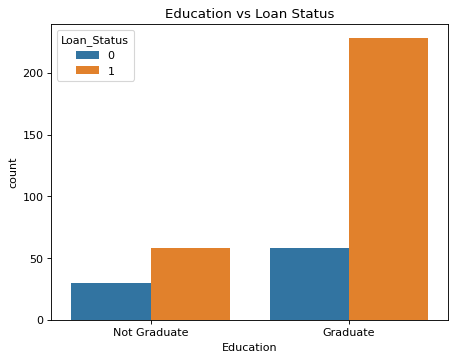

In [15]:
# education & Loan Status
sns.countplot(x='Education', hue='Loan_Status', data=loan_dataset)
plt.title('Education vs Loan Status')
plt.show()


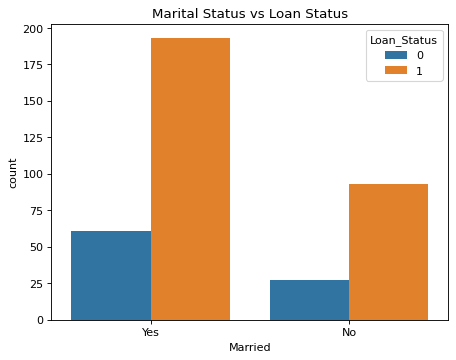

In [16]:
# marital status & Loan Status
sns.countplot(x='Married', hue='Loan_Status', data=loan_dataset)
plt.title('Marital Status vs Loan Status')
plt.show()


In [17]:
# convert categorical columns to numerical values
loan_dataset.replace({'Married':{'No':0,'Yes':1},
                       'Gender':{'Male':1,'Female':0},
                       'Self_Employed':{'No':0,'Yes':1},
                       'Property_Area':{'Rural':0,'Semiurban':1,'Urban':2},
                       'Education':{'Graduate':1,'Not Graduate':0}}, inplace=True)


      Loan_ID Gender Married  ... Credit_History Property_Area Loan_Status
0    LP100000      1       1  ...            1.0             2           1
3    LP100003      1       1  ...            1.0             2           1
4    LP100004      1       1  ...            1.0             0           1
5    LP100005      1       0  ...            1.0             1           1
6    LP100006      1       1  ...            1.0             1           1
..        ...    ...     ...  ...            ...           ...         ...
473  LP100473      0       0  ...            1.0             2           1
474  LP100474      1       1  ...            1.0             0           0
475  LP100475      0       1  ...            0.0             0           0
476  LP100476      1       1  ...            1.0             1           1
479  LP100479      1       0  ...            1.0             1           1

[374 rows x 13 columns]

In [18]:
loan_dataset.head()

    Loan_ID Gender Married  ... Credit_History Property_Area Loan_Status
0  LP100000      1       1  ...            1.0             2           1
3  LP100003      1       1  ...            1.0             2           1
4  LP100004      1       1  ...            1.0             0           1
5  LP100005      1       0  ...            1.0             1           1
6  LP100006      1       1  ...            1.0             1           1

[5 rows x 13 columns]

In [19]:
# separating the data and label
X = loan_dataset.drop(columns=['Loan_ID','Loan_Status'])
Y = loan_dataset['Loan_Status']

# make sure every feature column is numeric (float)
X = X.astype(float)


In [20]:
print(X)
print(Y)


     Gender  Married  ...  Credit_History  Property_Area
0       1.0      1.0  ...             1.0            2.0
3       1.0      1.0  ...             1.0            2.0
4       1.0      1.0  ...             1.0            0.0
5       1.0      0.0  ...             1.0            1.0
6       1.0      1.0  ...             1.0            1.0
..      ...      ...  ...             ...            ...
473     0.0      0.0  ...             1.0            2.0
474     1.0      1.0  ...             1.0            0.0
475     0.0      1.0  ...             0.0            0.0
476     1.0      1.0  ...             1.0            1.0
479     1.0      0.0  ...             1.0            1.0

[374 rows x 11 columns]
0      1
3      1
4      1
5      1
6      1
      ..
473    1
474    0
475    0
476    1
479    1
Name: Loan_Status, Length: 374, dtype: int64


## 4. Train Test Split

In [21]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.1, stratify=Y, random_state=2)


In [22]:
print(X.shape, X_train.shape, X_test.shape)

(374, 11) (336, 11) (38, 11)


## 5. Training the Model

### Support Vector Machine Model

In [23]:
classifier = svm.SVC(kernel='linear')

In [24]:
# training the Support Vector Machine model
classifier.fit(X_train, Y_train)


SVC(kernel='linear')

## 6. Model Evaluation

In [25]:
# accuracy score on training data
X_train_prediction = classifier.predict(X_train)
training_data_accuracy = accuracy_score(X_train_prediction, Y_train)


In [26]:
print('Accuracy on training data : ', training_data_accuracy)

Accuracy on training data :  0.7886904761904762


In [27]:
# accuracy score on test data
X_test_prediction = classifier.predict(X_test)
test_data_accuracy = accuracy_score(X_test_prediction, Y_test)


In [28]:
print('Accuracy on test data : ', test_data_accuracy)

Accuracy on test data :  0.7631578947368421


## 7. Making a Predictive System

In [29]:
# Column order used during training (must match for new predictions)
feature_columns = X.columns.tolist()
print(feature_columns)


['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area']


In [30]:
def predict_loan_status(input_data: dict):
    """
    Predict loan approval status from raw applicant details.

    input_data keys (raw, human-readable values):
      Gender         : 'Male' / 'Female'
      Married        : 'Yes' / 'No'
      Dependents     : '0', '1', '2', '3+'
      Education      : 'Graduate' / 'Not Graduate'
      Self_Employed  : 'Yes' / 'No'
      ApplicantIncome    : number
      CoapplicantIncome  : number
      LoanAmount         : number
      Loan_Amount_Term   : number (in days, e.g. 360)
      Credit_History     : 1.0 or 0.0
      Property_Area      : 'Rural' / 'Semiurban' / 'Urban'
    """
    data = input_data.copy()

    # apply the same encodings used during training
    gender_map = {'Male': 1, 'Female': 0}
    married_map = {'No': 0, 'Yes': 1}
    education_map = {'Graduate': 1, 'Not Graduate': 0}
    self_employed_map = {'No': 0, 'Yes': 1}
    property_area_map = {'Rural': 0, 'Semiurban': 1, 'Urban': 2}
    dependents_map = {'0': 0, '1': 1, '2': 2, '3+': 4, 0: 0, 1: 1, 2: 2, 4: 4}

    data['Gender'] = gender_map.get(data['Gender'], data['Gender'])
    data['Married'] = married_map.get(data['Married'], data['Married'])
    data['Education'] = education_map.get(data['Education'], data['Education'])
    data['Self_Employed'] = self_employed_map.get(data['Self_Employed'], data['Self_Employed'])
    data['Property_Area'] = property_area_map.get(data['Property_Area'], data['Property_Area'])
    data['Dependents'] = dependents_map.get(data['Dependents'], data['Dependents'])

    # build a one-row DataFrame in the exact column order used for training
    input_df = pd.DataFrame([data])[feature_columns].astype(float)

    prediction = classifier.predict(input_df)[0]
    return 'Approved (Y)' if prediction == 1 else 'Rejected (N)'


In [31]:
# Example: predict loan status for a new applicant
sample_applicant = {
    'Gender': 'Male',
    'Married': 'Yes',
    'Dependents': '0',
    'Education': 'Graduate',
    'Self_Employed': 'No',
    'ApplicantIncome': 5000,
    'CoapplicantIncome': 2000,
    'LoanAmount': 150,
    'Loan_Amount_Term': 360,
    'Credit_History': 1.0,
    'Property_Area': 'Urban'
}

result = predict_loan_status(sample_applicant)
print('Loan Status Prediction:', result)


Loan Status Prediction: Approved (Y)
